In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import lu
from PIL import Image
import requests
from io import BytesIO

In [8]:
def cargar_imagen_grises_como_cuadrada(ruta_o_url, tamaño_cuadrado=None):
    """
    Carga una imagen y la convierte a escala de grises y cuadrada.
    
    Parámetros:
    -----------
    ruta_o_url : str
        Ruta local o URL de la imagen
    tamaño_cuadrado : int, opcional
        Si se proporciona, redimensiona a (tamaño_cuadrado, tamaño_cuadrado).
        Si no se proporciona, toma el menor lado y recorta al centro para hacerla cuadrada.
    
    Retorna:
    --------
    matriz : numpy.ndarray (2D) de floats en [0,1]
    tamaño : int (n)
    """
    # Cargar imagen
    if ruta_o_url.startswith('http://') or ruta_o_url.startswith('https://'):
        respuesta = requests.get(ruta_o_url)
        img = Image.open(BytesIO(respuesta.content))
    else:
        img = Image.open(ruta_o_url)
    
    # Convertir a escala de grises
    img_gris = img.convert('L')
    
    # Hacerla cuadrada
    if tamaño_cuadrado is not None:
        # Redimensionar directamente al tamaño deseado
        img_cuadrada = img_gris.resize((tamaño_cuadrado, tamaño_cuadrado), Image.Resampling.LANCZOS)
        n = tamaño_cuadrado
    else:
        # Hacer cuadrada recortando al centro
        ancho, alto = img_gris.size
        lado = min(ancho, alto)
        izquierda = (ancho - lado) // 2
        superior = (alto - lado) // 2
        img_cuadrada = img_gris.crop((izquierda, superior, izquierda + lado, superior + lado))
        n = lado
    
    # Convertir a numpy y normalizar
    matriz = np.array(img_cuadrada, dtype=np.float64) / 255.0
    
    print(f"Imagen cargada como cuadrada de tamaño {n}x{n}")
    return matriz, n

In [9]:
def cifrar_imagen(A_c, A_s, alpha):
    """
    Cifra A_s dentro de A_c usando factorización LU.
    A_c y A_s deben ser matrices cuadradas del mismo tamaño.
    """
    # Factorización LU de la cobertura
    P_c, L_c, U_c = lu(A_c)
    
    # Factorización LU de la secreta
    P_s, L_s, U_s = lu(A_s)
    
    # Mezcla
    A_e = L_c @ (U_c + alpha * U_s)
    
    return A_e, L_s, U_c  # U_c se guarda para descifrar


In [10]:
def descifrar_imagen(A_e, L_s, U_c, alpha):
    """
    Descifra para recuperar A_s.
    """
    P_e, L_e, U_e = lu(A_e)
    
    U_s_recuperada = (U_e - U_c) / alpha
    
    A_s_descifrada = L_s @ U_s_recuperada
    
    return A_s_descifrada

In [11]:
def visualizar_comparacion(A_c, A_s, A_e, A_s_desc, titulos=None):
    """
    Muestra las 4 imágenes en una cuadrícula.
    """
    if titulos is None:
        titulos = ["Cobertura", "Secreta original", "Esteganográfica", "Descifrada"]
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    imagenes = [A_c, A_s, A_e, A_s_desc]
    for i, (ax, img, tit) in enumerate(zip(axes, imagenes, titulos)):
        ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        ax.set_title(tit)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

Imagen cargada como cuadrada de tamaño 626x626

Ambas imágenes redimensionadas a 626x626

--- CIFRANDO ---
Imagen esteganográfica generada

--- DESCIFRANDO ---
Imagen secreta recuperada


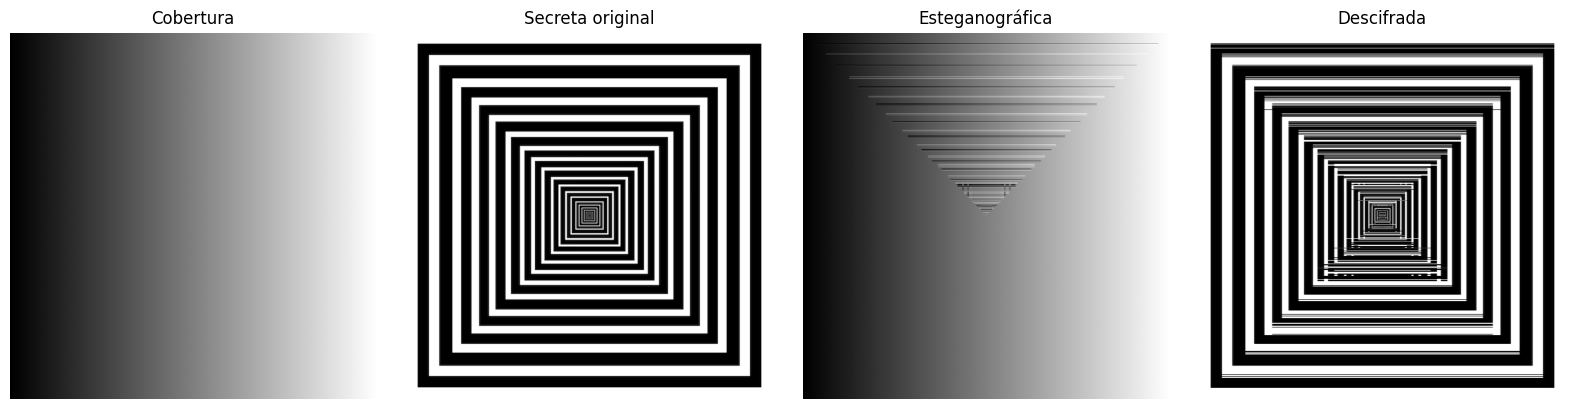


Error relativo de reconstrucción: 3.95e-01


In [12]:
ruta_secreta = "/Users/claudialbombin/Desktop/2025 - 2026/Practicas/Metodos/P6/extracto-cuadrado-color-blanco-negro-sorprende-fondo_38782-108.jpg.avif" 
try:
    # PASO 1: Cargar la imagen secreta con el MISMO tamaño n
    A_s, n = cargar_imagen_grises_como_cuadrada(ruta_secreta, tamaño_cuadrado=None)
    # PASO 2: Cargar la imagen de cobertura y obtener su tamaño n
    A_c = np.linspace(0, 1, n).reshape(1, n) + np.zeros((n, 1))
    A_c = A_c / np.max(A_c)

    
    print(f"\nAmbas imágenes redimensionadas a {n}x{n}")
    
    alpha = 0.3  # Parámetro de mezcla (ajústalo si ves ruido)
    
    # Cifrar
    print("\n--- CIFRANDO ---")
    A_e, L_s, U_c = cifrar_imagen(A_c, A_s, alpha)
    print("Imagen esteganográfica generada")
    
    # Descifrar
    print("\n--- DESCIFRANDO ---")
    A_s_desc = descifrar_imagen(A_e, L_s, U_c, alpha)
    print("Imagen secreta recuperada")
    
    # Visualizar
    visualizar_comparacion(A_c, A_s, A_e, A_s_desc)
    
    # Error
    error = np.linalg.norm(A_s - A_s_desc) / np.linalg.norm(A_s)
    print(f"\nError relativo de reconstrucción: {error:.2e}")
    
except FileNotFoundError:
    print("\nError: No se encontró el archivo. Revisa las rutas de las imágenes.")
    print("   Asegúrate de que los archivos existan y las rutas sean correctas.")
    
except Exception as e:
    print(f"\n Error inesperado: {e}")
    print("\nProbando con imágenes sintéticas de respaldo...")

    # Opción de respaldo: imágenes sintéticas
    n = 128
    # Cobertura: degradado
    A_c = np.linspace(0, 1, n).reshape(1, n) + np.zeros((n, 1))
    A_c = A_c / np.max(A_c)
    # Secreta: círculo blanco
    A_s = np.zeros((n, n))
    centro = n // 2
    radio = n // 4
    for i in range(n):
        for j in range(n):
            if (i - centro)**2 + (j - centro)**2 < radio**2:
                A_s[i, j] = 0.9
    
    alpha = 0.5
    
    print(f"Usando imágenes sintéticas de tamaño {n}x{n}")
    A_e, L_s, U_c = cifrar_imagen(A_c, A_s, alpha)
    A_s_desc = descifrar_imagen(A_e, L_s, U_c, alpha)
    
    visualizar_comparacion(A_c, A_s, A_e, A_s_desc)
    error = np.linalg.norm(A_s - A_s_desc) / np.linalg.norm(A_s)
    print(f"\nError relativo: {error:.2e}")

In [13]:
def cargar_imagen_rgb(ruta, tamanyo_cuadrado=None):
    """
    Carga una imagen RGB desde archivo local.

    Retorna la matriz normalizada en [0, 1] con forma (n, n, 3).
    """
    img = Image.open(ruta).convert('RGB')

    if tamanyo_cuadrado is not None:
        img = img.resize((tamanyo_cuadrado, tamanyo_cuadrado), Image.Resampling.LANCZOS)
        n = tamanyo_cuadrado
    else:
        ancho, alto = img.size
        lado = min(ancho, alto)
        izq = (ancho - lado) // 2
        sup = (alto - lado) // 2
        img = img.crop((izq, sup, izq + lado, sup + lado))
        n = lado

    matriz = np.array(img, dtype=np.float64) / 255.0
    print(f"Imagen RGB cargada: {n}x{n} pixeles")
    return matriz, n

In [14]:
def generar_cobertura_rgb(n, tipo="arcoiris"):
    """
    Genera una imagen de cobertura RGB sintetica de tamanyo n x n.

    Tipos disponibles: 'degradados', 'ruido', 'colores_solidos', 'arcoiris'.
    """
    A_c = np.zeros((n, n, 3))

    if tipo == "degradados":
        A_c[:, :, 0] = np.linspace(0, 1, n).reshape(1, n)
        A_c[:, :, 1] = np.linspace(0, 1, n).reshape(n, 1)
        A_c[:, :, 2] = 0.5

    elif tipo == "ruido":
        A_c[:, :, 0] = np.random.rand(n, n)
        A_c[:, :, 1] = np.random.rand(n, n)
        A_c[:, :, 2] = np.random.rand(n, n)

    elif tipo == "colores_solidos":
        m = n // 2
        A_c[:m, :m, 0] = 1.0
        A_c[:m, m:, 1] = 1.0
        A_c[m:, :m, 2] = 1.0
        A_c[m:, m:, 0] = 1.0
        A_c[m:, m:, 1] = 1.0

    else:  # arcoiris por defecto
        ii, jj = np.meshgrid(np.arange(n), np.arange(n), indexing='ij')
        A_c[:, :, 0] = (ii + jj) / (2 * n)
        A_c[:, :, 1] = ii / n
        A_c[:, :, 2] = jj / n

    print(f"Cobertura RGB generada (tipo: {tipo}, tamanyo: {n}x{n})")
    return A_c

In [15]:
def generar_secreta_sintetica(n, tipo="diagonal"):
    """
    Genera una imagen secreta RGB sintetica de tamanyo n x n.

    Tipos disponibles: 'cuadrado', 'circulo', 'diagonal'.
    """
    A_s = np.zeros((n, n, 3))
    centro = n // 2

    if tipo == "cuadrado":
        tam = n // 6
        A_s[centro - tam:centro + tam, centro - tam:centro + tam, 1] = 1.0
        A_s[centro - tam:centro + tam, centro - tam:centro + tam, 2] = 1.0

    elif tipo == "circulo":
        radio = n // 5
        ii, jj = np.meshgrid(np.arange(n), np.arange(n), indexing='ij')
        mascara = (ii - centro) ** 2 + (jj - centro) ** 2 < radio ** 2
        A_s[mascara, 0] = 1.0
        A_s[mascara, 2] = 1.0

    elif tipo == "diagonal":
        idx = np.arange(n)
        A_s[idx, idx, 0] = 1.0

    print(f"Secreta sintetica generada (tipo: {tipo}, tamanyo: {n}x{n})")
    return A_s

In [16]:
def cifrar_rgb(A_c, A_s, alpha):
    """
    Cifrado de una imagen secreta en color RGB mediante factorizacion LU.

    El algoritmo sigue exactamente el enunciado:
        [Lc, Uc] = lu(Ac)
        [Ls, Us] = lu(As)
        Ae = Lc * (Uc + alpha * Us)

    Cada canal R, G, B se trata como una matriz independiente.

    Parametros
    ----------
    A_c : ndarray (n, n, 3)
        Imagen de cobertura, valores en [0, 1].
    A_s : ndarray (n, n, 3)
        Imagen secreta, valores en [0, 1].
    alpha : float
        Parametro de mezcla (alpha > 0).

    Retorna
    -------
    A_e : ndarray (n, n, 3)
        Imagen esteganografica.
    clave : dict
        Clave de descifrado: contiene Ls y Uc por canal, mas alpha.
        Equivale a (Ae, Ls) del enunciado; Uc se guarda porque el receptor
        necesita conocer Ac (o equivalentemente Uc) para descifrar.
    """
    n = A_c.shape[0]
    A_e = np.zeros_like(A_c)
    Ls_canales = []
    Uc_canales = []

    for c in range(3):
        _, Lc, Uc = lu(A_c[:, :, c])
        _, Ls, Us = lu(A_s[:, :, c])

        A_e[:, :, c] = Lc @ (Uc + alpha * Us)

        Ls_canales.append(Ls)
        Uc_canales.append(Uc)

    clave = {"Ls": Ls_canales, "Uc": Uc_canales, "alpha": alpha}
    print("Cifrado completado.")
    return A_e, clave

In [17]:
def descifrar_rgb(A_e, clave):
    """
    Descifrado de la imagen esteganografica para recuperar la imagen secreta.

    El algoritmo sigue exactamente el enunciado:
        [Le, Ue] = lu(Ae)
        As = Ls * (1/alpha) * (Ue - Uc)

    Parametros
    ----------
    A_e : ndarray (n, n, 3)
        Imagen esteganografica recibida.
    clave : dict
        Clave generada durante el cifrado (Ls, Uc, alpha por canal).

    Retorna
    -------
    A_s_rec : ndarray (n, n, 3)
        Imagen secreta recuperada.
    """
    Ls_canales = clave["Ls"]
    Uc_canales = clave["Uc"]
    alpha = clave["alpha"]

    A_s_rec = np.zeros_like(A_e)

    for c in range(3):
        _, Le, Ue = lu(A_e[:, :, c])

        # Segun el enunciado: As = Ls * (1/alpha) * (Ue - Uc)
        Us_rec = (Ue - Uc_canales[c]) / alpha
        A_s_rec[:, :, c] = Ls_canales[c] @ Us_rec

    print("Descifrado completado.")
    return A_s_rec

In [18]:
def explicar_problema_tensor():
    """
    Explica por que tratar la imagen RGB como un unico tensor 3D
    no es compatible con la factorizacion LU, e ilustra el fallo
    numericamente con un ejemplo pequenyo.
    """
    print()
    print("Apartado e): Por que no funciona tratar la imagen RGB como tensor 3D")
    print("-" * 70)

    explicacion = (
        "La factorizacion LU esta definida exclusivamente para matrices\n"
        "bidimensionales. Una imagen en color es un tensor de orden 3\n"
        "(alto x ancho x canales), por lo que no admite LU directamente.\n"
        "\n"
        "Una estrategia tentadora consiste en apilar los tres canales y\n"
        "construir una unica matriz 2D, por ejemplo de dimension n x (3n)\n"
        "o (3n) x n, aplicar LU sobre ella y luego separar el resultado.\n"
        "El problema es que esto no funciona por las siguientes razones:\n"
        "\n"
        "1. Mezclado de informacion entre canales.\n"
        "   Al concatenar los canales en una sola matriz, la factorizacion\n"
        "   LU introduce dependencias entre filas o columnas que pertenecen\n"
        "   a canales distintos. L y U ya no son separables por canal, de\n"
        "   modo que al intentar recuperar cada canal por separado se\n"
        "   obtiene una mezcla incorrecta de los tres.\n"
        "\n"
        "2. Perdida de la estructura de la mezcla.\n"
        "   El cifrado construye Ae = Lc * (Uc + alpha * Us) canal a canal.\n"
        "   Si en cambio se forma una matriz aumentada M_c con los tres\n"
        "   canales de A_c y se factoriza como [L, U] = lu(M_c), la matriz\n"
        "   L obtenida no coincide con el apilamiento de las Lc individuales.\n"
        "   En consecuencia, el descifrado As = Ls * (1/alpha) * (Ue - Uc)\n"
        "   no puede aplicarse de forma coherente.\n"
        "\n"
        "3. No existe una generalizacion canonica de LU a tensores.\n"
        "   A diferencia de otros objetos del algebra lineal tensorial\n"
        "   (como la SVD, que si admite generalizacion via descomposicion\n"
        "   de Tucker o HOSVD), la factorizacion LU no tiene un analogo\n"
        "   para tensores de orden superior que conserve las propiedades\n"
        "   de triangularidad y que sea invertible canal a canal.\n"
        "\n"
        "Solucion correcta: aplicar LU de forma independiente a cada canal\n"
        "y recomponer el tensor al final. Asi se preserva la estructura de\n"
        "la imagen, el cifrado es invertible y el error de reconstruccion\n"
        "queda en el orden de la precision de punto flotante."
    )

    print(explicacion)

    # Demostracion numerica del fallo
    print()
    print("Demostracion numerica:")
    np.random.seed(0)
    n = 4
    A_c = np.random.rand(n, n, 3)
    A_s = np.random.rand(n, n, 3)
    alpha = 0.3

    # Enfoque canal a canal (correcto)
    _, clave = cifrar_rgb(A_c, A_s, alpha)
    A_s_correcto = descifrar_rgb(cifrar_rgb(A_c, A_s, alpha)[0], clave)
    error_correcto = np.linalg.norm(A_s - A_s_correcto)

    # Enfoque tensorial (incorrecto): se apilan los canales en columnas
    M_c = np.hstack([A_c[:, :, c] for c in range(3)])  # n x (3n)
    M_s = np.hstack([A_s[:, :, c] for c in range(3)])
    _, Lc_t, Uc_t = lu(M_c)
    _, Ls_t, Us_t = lu(M_s)
    M_e = Lc_t @ (Uc_t + alpha * Us_t)
    _, Le_t, Ue_t = lu(M_e)
    M_s_rec = Ls_t @ ((Ue_t - Uc_t) / alpha)
    # Separar canales del resultado
    A_s_tensor = np.stack(
        [M_s_rec[:, c * n:(c + 1) * n] for c in range(3)], axis=2
    )
    error_tensor = np.linalg.norm(A_s - A_s_tensor)

    print(f"  Error de reconstruccion (canal a canal): {error_correcto:.2e}")
    print(f"  Error de reconstruccion (enfoque tensorial): {error_tensor:.2e}")
    print()
    if error_tensor > 1e-6:
        print("  El enfoque tensorial no recupera la imagen secreta correctamente.")
    else:
        print("  (Coincidencia numerica inesperada en este ejemplo.)")



In [19]:
def visualizar(A_c, A_s, A_e, A_s_rec, guardar=False, nombre="comparacion_rgb.png"):
    """Muestra las cuatro imagenes en una fila."""
    titulos = ["Cobertura", "Secreta original", "Esteganografica", "Secreta recuperada"]
    imagenes = [A_c, A_s, A_e, A_s_rec]

    fig, ejes = plt.subplots(1, 4, figsize=(16, 4))
    for ax, img, tit in zip(ejes, imagenes, titulos):
        ax.imshow(np.clip(img, 0, 1))
        ax.set_title(tit, fontsize=11)
        ax.axis('off')

    plt.tight_layout()
    if guardar:
        plt.savefig(nombre, dpi=150, bbox_inches='tight')
        print(f"Figura guardada como '{nombre}'")
    plt.show()

Parte rgb
Cobertura RGB generada (tipo: arcoiris, tamanyo: 128x128)
Imagen RGB cargada: 128x128 pixeles
Alpha = 0.3
Cifrado completado.
Descifrado completado.
Error relativo de reconstruccion: 3.11e+00
Advertencia: el error es mayor de lo esperado.
Figura guardada como 'comparacion_rgb.png'


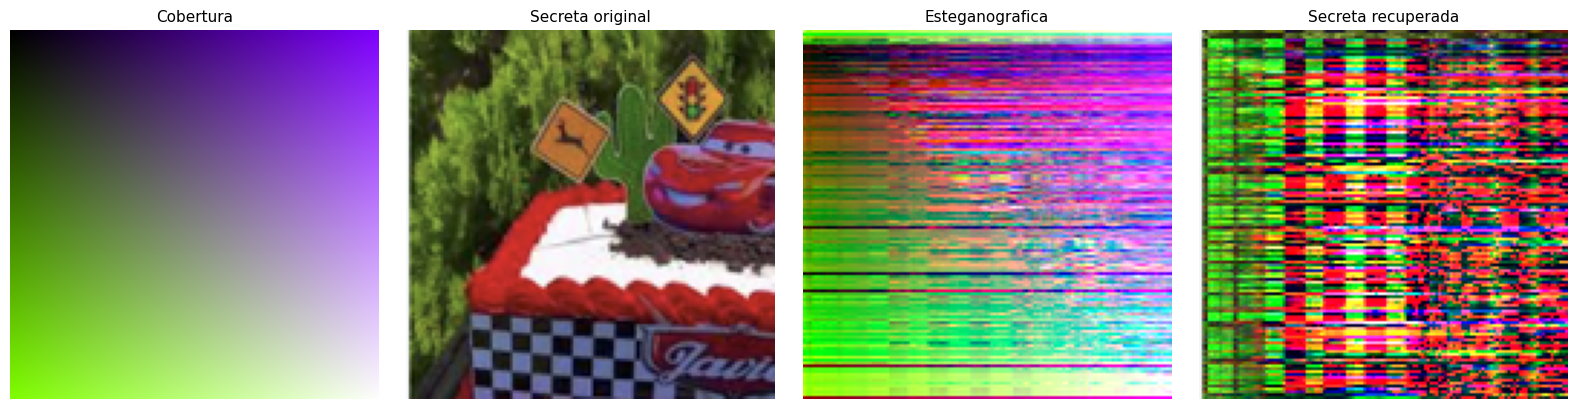


Apartado e): Por que no funciona tratar la imagen RGB como tensor 3D
----------------------------------------------------------------------
La factorizacion LU esta definida exclusivamente para matrices
bidimensionales. Una imagen en color es un tensor de orden 3
(alto x ancho x canales), por lo que no admite LU directamente.

Una estrategia tentadora consiste en apilar los tres canales y
construir una unica matriz 2D, por ejemplo de dimension n x (3n)
o (3n) x n, aplicar LU sobre ella y luego separar el resultado.
El problema es que esto no funciona por las siguientes razones:

1. Mezclado de informacion entre canales.
   Al concatenar los canales en una sola matriz, la factorizacion
   LU introduce dependencias entre filas o columnas que pertenecen
   a canales distintos. L y U ya no son separables por canal, de
   modo que al intentar recuperar cada canal por separado se
   obtiene una mezcla incorrecta de los tres.

2. Perdida de la estructura de la mezcla.
   El cifrado construye

In [22]:
print("Parte rgb")

# Parametros
TAMANYO = 128
ALPHA = 0.3
TIPO_COBERTURA = "arcoiris"

# Ruta a la imagen secreta real (None para usar imagen sintetica)
RUTA_SECRETA = '/Users/claudialbombin/Desktop/2025 - 2026/Practicas/Metodos/P6/Screenshot 2026-04-14 at 09.32.55.png'
# RUTA_SECRETA = "ruta/a/tu/imagen.jpg"

# Cobertura
A_c = generar_cobertura_rgb(TAMANYO, tipo=TIPO_COBERTURA)

# Secreta
if RUTA_SECRETA is not None:
    try:
        A_s, _ = cargar_imagen_rgb(RUTA_SECRETA, tamanyo_cuadrado=TAMANYO)
    except Exception as e:
        print(f"No se pudo cargar la imagen ({e}). Se usa imagen sintetica.")
        A_s = generar_secreta_sintetica(TAMANYO, tipo="cuadrado")
else:
    A_s = generar_secreta_sintetica(TAMANYO, tipo="cuadrado")

print(f"Alpha = {ALPHA}")

# Cifrado
A_e, clave = cifrar_rgb(A_c, A_s, ALPHA)

# Descifrado
A_s_rec = descifrar_rgb(A_e, clave)

# Metricas
norma_s = np.linalg.norm(A_s)
error_rel = np.linalg.norm(A_s - A_s_rec) / norma_s if norma_s > 0 else float('inf')
print(f"Error relativo de reconstruccion: {error_rel:.2e}")

if error_rel < 1e-8:
    print("Recuperacion correcta dentro de la precision numerica.")
else:
    print("Advertencia: el error es mayor de lo esperado.")

# Visualizacion
visualizar(A_c, A_s, A_e, A_s_rec, guardar=True)

# Apartado e
explicar_problema_tensor()